# Lab 8 - DuckDB

Resultados de taxis amarillos y verdes de 2024, 2025 y 2026.

In [1]:
from pathlib import Path
import sys
root = Path.cwd()
if root.name == 'notebooks':
    root = root.parent
sys.path.insert(0, str(root / 'scripts'))
from common import connect, files, views, sql
import pandas as pd
from IPython.display import display, Image
con = connect()
views(con, files([2024, 2025, 2026]))

## Archivos, registros y tipos

In [2]:
display(con.execute(sql('coverage')).fetchdf())
display(pd.read_csv(root / 'docs/results/2024_2025_2026/schema.csv'))

,taxi,source_year,files,rows,first_pickup,last_pickup
0,green,2024,12,660218,2008-12-31 00:00:00,2025-01-01 22:21:15
1,green,2025,12,591375,2008-12-31 15:13:04,2026-01-01 21:09:39
2,green,2026,8,337114,2008-12-31 17:35:31,2026-08-31 23:58:28
3,yellow,2024,12,41169720,2002-12-31 16:46:07,2026-06-26 23:53:12
4,yellow,2025,12,48722602,2007-12-05 18:45:00,2025-12-31 23:59:59
5,yellow,2026,8,29703355,2001-01-01 09:23:58,2026-08-31 23:59:59


,column_name,column_type,null,key,default,extra
0,VendorID,INTEGER,YES,NaN,NaN,NaN
1,lpep_pickup_datetime,TIMESTAMP,YES,NaN,NaN,NaN
2,lpep_dropoff_datetime,TIMESTAMP,YES,NaN,NaN,NaN
3,store_and_fwd_flag,VARCHAR,YES,NaN,NaN,NaN
4,RatecodeID,BIGINT,YES,NaN,NaN,NaN
5,PULocationID,INTEGER,YES,NaN,NaN,NaN
6,DOLocationID,INTEGER,YES,NaN,NaN,NaN
7,passenger_count,BIGINT,YES,NaN,NaN,NaN
8,trip_distance,DOUBLE,YES,NaN,NaN,NaN
9,fare_amount,DOUBLE,YES,NaN,NaN,NaN


## Muestra y calidad

In [3]:
display(con.execute('SELECT * FROM trips_raw ORDER BY source_file, pickup LIMIT 10').fetchdf())
display(con.execute(sql('quality')).fetchdf())

,taxi,source_year,source_month,source_file,pickup,dropoff,passenger_count,trip_distance,fare_amount,total_amount,tip_amount,payment_type,pickup_zone,dropoff_zone,cbd_congestion_fee,duration_minutes
0,green,2024,1,/workspace/data/raw/green/2024/green_tripdata_...,2023-12-31 14:38:47,2023-12-31 14:46:45,1,0.95,8.6,13.88,2.78,1,25,65,NaN,7.966667
1,green,2024,1,/workspace/data/raw/green/2024/green_tripdata_...,2023-12-31 23:38:54,2023-12-31 23:50:09,1,4.85,21.2,23.70,0.00,1,74,235,NaN,11.250000
2,green,2024,1,/workspace/data/raw/green/2024/green_tripdata_...,2024-01-01 00:03:57,2024-01-01 00:18:06,1,5.06,23.3,33.54,7.74,1,130,196,NaN,14.150000
3,green,2024,1,/workspace/data/raw/green/2024/green_tripdata_...,2024-01-01 00:04:49,2024-01-01 00:15:09,1,2.60,13.5,16.00,0.00,2,210,123,NaN,10.333333
4,green,2024,1,/workspace/data/raw/green/2024/green_tripdata_...,2024-01-01 00:05:50,2024-01-01 00:06:18,1,0.02,13.0,14.00,0.00,1,159,159,NaN,0.466667
5,green,2024,1,/workspace/data/raw/green/2024/green_tripdata_...,2024-01-01 00:06:00,2024-01-01 00:56:26,1,4.15,45.0,60.25,10.00,1,66,148,NaN,50.433333
6,green,2024,1,/workspace/data/raw/green/2024/green_tripdata_...,2024-01-01 00:06:59,2024-01-01 00:17:18,1,1.86,12.8,15.30,0.00,2,95,135,NaN,10.316667
7,green,2024,1,/workspace/data/raw/green/2024/green_tripdata_...,2024-01-01 00:07:52,2024-01-01 00:23:45,1,8.51,33.8,40.16,1.11,1,74,232,NaN,15.883333
8,green,2024,1,/workspace/data/raw/green/2024/green_tripdata_...,2024-01-01 00:08:00,2024-01-01 00:11:49,2,0.72,6.5,9.00,0.00,2,82,83,NaN,3.816667
9,green,2024,1,/workspace/data/raw/green/2024/green_tripdata_...,2024-01-01 00:08:05,2024-01-01 00:25:10,6,5.72,26.1,31.35,0.00,2,41,233,NaN,17.083333


,taxi,source_year,rows,missing_pickup,wrong_period,invalid_distance,invalid_duration,invalid_total,missing_passengers,zero_passengers,extreme_values
0,green,2024,660218,0,164,34574,3641,2574,24328,6793,270
1,green,2025,591375,0,248,24438,4617,2706,49880,8255,231
2,green,2026,337114,0,98,12212,1521,1566,48775,4527,92
3,yellow,2024,41169720,0,420,776305,38859,614406,4091232,401354,2219
4,yellow,2025,48722602,0,214,1402958,564705,980522,11611894,260062,3854
5,yellow,2026,29703355,0,146,952231,381810,167093,7716688,91359,1822


## An?lisis exploratorio

Viajes mensuales, horarios, pagos, distribuciones y zonas.

In [4]:
for name in ['monthly', 'hourly', 'payments', 'distribution', 'zones']:
    print(name)
    display(pd.read_csv(root / 'docs/results/2024_2025_2026' / f'{name}.csv'))

monthly


,taxi,source_year,source_month,trips,mean_total,median_total,mean_distance,mean_duration,revenue
0,green,2024,1,53284,22.151559,18.35,2.752717,13.755746,1.180324e+06
1,green,2024,2,50376,22.452832,18.40,2.783525,13.949154,1.131084e+06
2,green,2024,3,54071,22.718045,18.48,2.761968,14.147802,1.228387e+06
3,green,2024,4,52918,23.262562,18.85,2.808275,14.207947,1.231008e+06
4,green,2024,5,57428,24.459192,19.80,2.930617,15.225690,1.404642e+06
...,...,...,...,...,...,...,...,...,...
59,yellow,2026,4,3674137,30.088012,23.58,3.522260,18.058682,1.105475e+08
60,yellow,2026,5,3911798,30.536612,23.93,3.517179,18.802476,1.194531e+08
61,yellow,2026,6,3646340,30.588963,23.84,3.388992,17.571573,1.115378e+08
62,yellow,2026,7,3346167,30.122243,23.58,3.570760,17.245623,1.007941e+08


hourly


,taxi,hour,trips
0,green,0,24629
1,green,1,16375
2,green,2,11529
3,green,3,8909
4,green,4,8042
5,green,5,9458
6,green,6,26153
7,green,7,57961
8,green,8,74700
9,green,9,80174


payments


,taxi,source_year,payment_type,trips,mean_total,card_tip_percent
0,green,2024,1.0,426889,25.093174,22.371266
1,green,2024,2.0,167748,20.548620,NaN
2,green,2024,3.0,1981,14.972549,NaN
3,green,2024,4.0,681,14.484949,NaN
4,green,2024,5.0,21,19.390476,NaN
5,green,2024,NaN,23453,31.972262,NaN
6,green,2025,1.0,387000,25.775061,22.502056
7,green,2025,2.0,124508,21.155467,NaN
8,green,2025,3.0,1576,15.616066,NaN
9,green,2025,4.0,520,15.681865,NaN


distribution


,taxi,source_year,distance_quantiles,total_quantiles,duration_quantiles
0,green,2024,[ 1.25 1.97 3.4 8.62 16.25],[13.9 19.25 28.02 55.24 94.13],[ 7.83333333 12. 18.01666667 34.3 ...
1,green,2025,[ 1.3 2.06 3.6 9.9 17.5255],[14.64 20.05 29.19 57.64 97.2 ],[ 8.26666667 12.66666667 19.18333333 38.933333...
2,green,2026,[ 1.33 2.14 3.77 10.62 17.66],[15.12 20.52 29.7 56.6 94.75],[ 8.66666667 13.3 20.58333333 43.866666...
3,yellow,2024,[ 1.06 1.8 3.4 14.44 20.05],[ 15.96 21.1 30.62 82.64 104.88],[ 7.96666667 13.08333333 21.16666667 44. ...
4,yellow,2025,[ 1.1 1.9 3.8 12.93 19.57],[ 16.05 21.54 31.05 77.5 104.03],[ 8.38333333 13.65 21.58333333 43.533333...
5,yellow,2026,[ 1.1 1.93 3.95 12.56 19.55],[ 17.5 23.58 34.5 77.25 104.96],[ 8.61666667 14.1 22.25 44.016666...


zones


,taxi,pickup_zone,trips
0,green,74,376372
1,green,75,212588
2,green,95,72801
3,green,43,72320
4,green,166,71227
5,green,41,61996
6,green,82,61071
7,green,97,49027
8,green,65,44578
9,green,130,41526


## Incorporaci?n de datos

Cobertura de las tres etapas.

In [5]:
for stage in ['2026', '2024_2026', '2024_2025_2026']:
    print(stage)
    display(pd.read_csv(root / 'docs/results' / stage / 'coverage.csv'))

2026


,taxi,source_year,files,rows,first_pickup,last_pickup
0,green,2026,8,337114,2008-12-31 17:35:31,2026-08-31 23:58:28
1,yellow,2026,8,29703355,2001-01-01 09:23:58,2026-08-31 23:59:59


2024_2026


,taxi,source_year,files,rows,first_pickup,last_pickup
0,green,2024,12,660218,2008-12-31 00:00:00,2025-01-01 22:21:15
1,green,2026,8,337114,2008-12-31 17:35:31,2026-08-31 23:58:28
2,yellow,2024,12,41169720,2002-12-31 16:46:07,2026-06-26 23:53:12
3,yellow,2026,8,29703355,2001-01-01 09:23:58,2026-08-31 23:59:59


2024_2025_2026


,taxi,source_year,files,rows,first_pickup,last_pickup
0,green,2024,12,660218,2008-12-31 00:00:00,2025-01-01 22:21:15
1,green,2025,12,591375,2008-12-31 15:13:04,2026-01-01 21:09:39
2,green,2026,8,337114,2008-12-31 17:35:31,2026-08-31 23:58:28
3,yellow,2024,12,41169720,2002-12-31 16:46:07,2026-06-26 23:53:12
4,yellow,2025,12,48722602,2007-12-05 18:45:00,2025-12-31 23:59:59
5,yellow,2026,8,29703355,2001-01-01 09:23:58,2026-08-31 23:59:59


## Comparaci?n entre a?os

Enero a agosto de cada a?o.

In [6]:
display(pd.read_csv(root / 'docs/results/2024_2025_2026/comparable.csv'))

,taxi,source_year,trips,mean_total,mean_distance,mean_duration,mean_cbd_fee
0,green,2024,416816.0,23.731069,2.912098,14.417074,NaN
1,green,2025,374777.0,24.835232,3.101140,15.277233,0.073743
2,green,2026,322429.0,25.401934,3.345085,17.099199,0.063577
3,yellow,2024,25569452.0,28.242913,3.418072,16.378580,NaN
4,yellow,2025,29792621.0,27.438375,3.454001,16.490989,0.547655
5,yellow,2026,28230818.0,30.234030,3.515682,17.664515,0.542987


## Benchmark

Medianas de tres repeticiones y tiempo de creaci?n de las tablas.

In [7]:
display(pd.read_csv(root / 'docs/results/benchmark_summary.csv'))
display(pd.read_csv(root / 'docs/results/materialization.csv'))

,files,rows,query,mode,median,min,max
0,2,3021175,hourly,duckdb,0.102447,0.069028,0.106433
1,2,3021175,hourly,parquet,0.253148,0.251879,0.299832
2,2,3021175,monthly,duckdb,0.211950,0.175924,0.214877
3,2,3021175,monthly,parquet,0.347407,0.305512,0.377506
4,2,3021175,payments,duckdb,0.100195,0.094372,0.122438
5,2,3021175,payments,parquet,0.314757,0.279473,0.336880
6,12,20671900,hourly,duckdb,0.587658,0.578334,0.781153
7,12,20671900,hourly,parquet,1.698133,1.562541,2.116454
8,12,20671900,monthly,duckdb,1.254913,1.020917,1.509326
9,12,20671900,monthly,parquet,2.177918,2.045038,2.445311


,files,rows,materialization_seconds
0,2,3021175,9.246540
1,12,20671900,26.016565
2,40,71870407,75.204994


## Tablero

Seis indicadores de actividad, costo y recorridos.

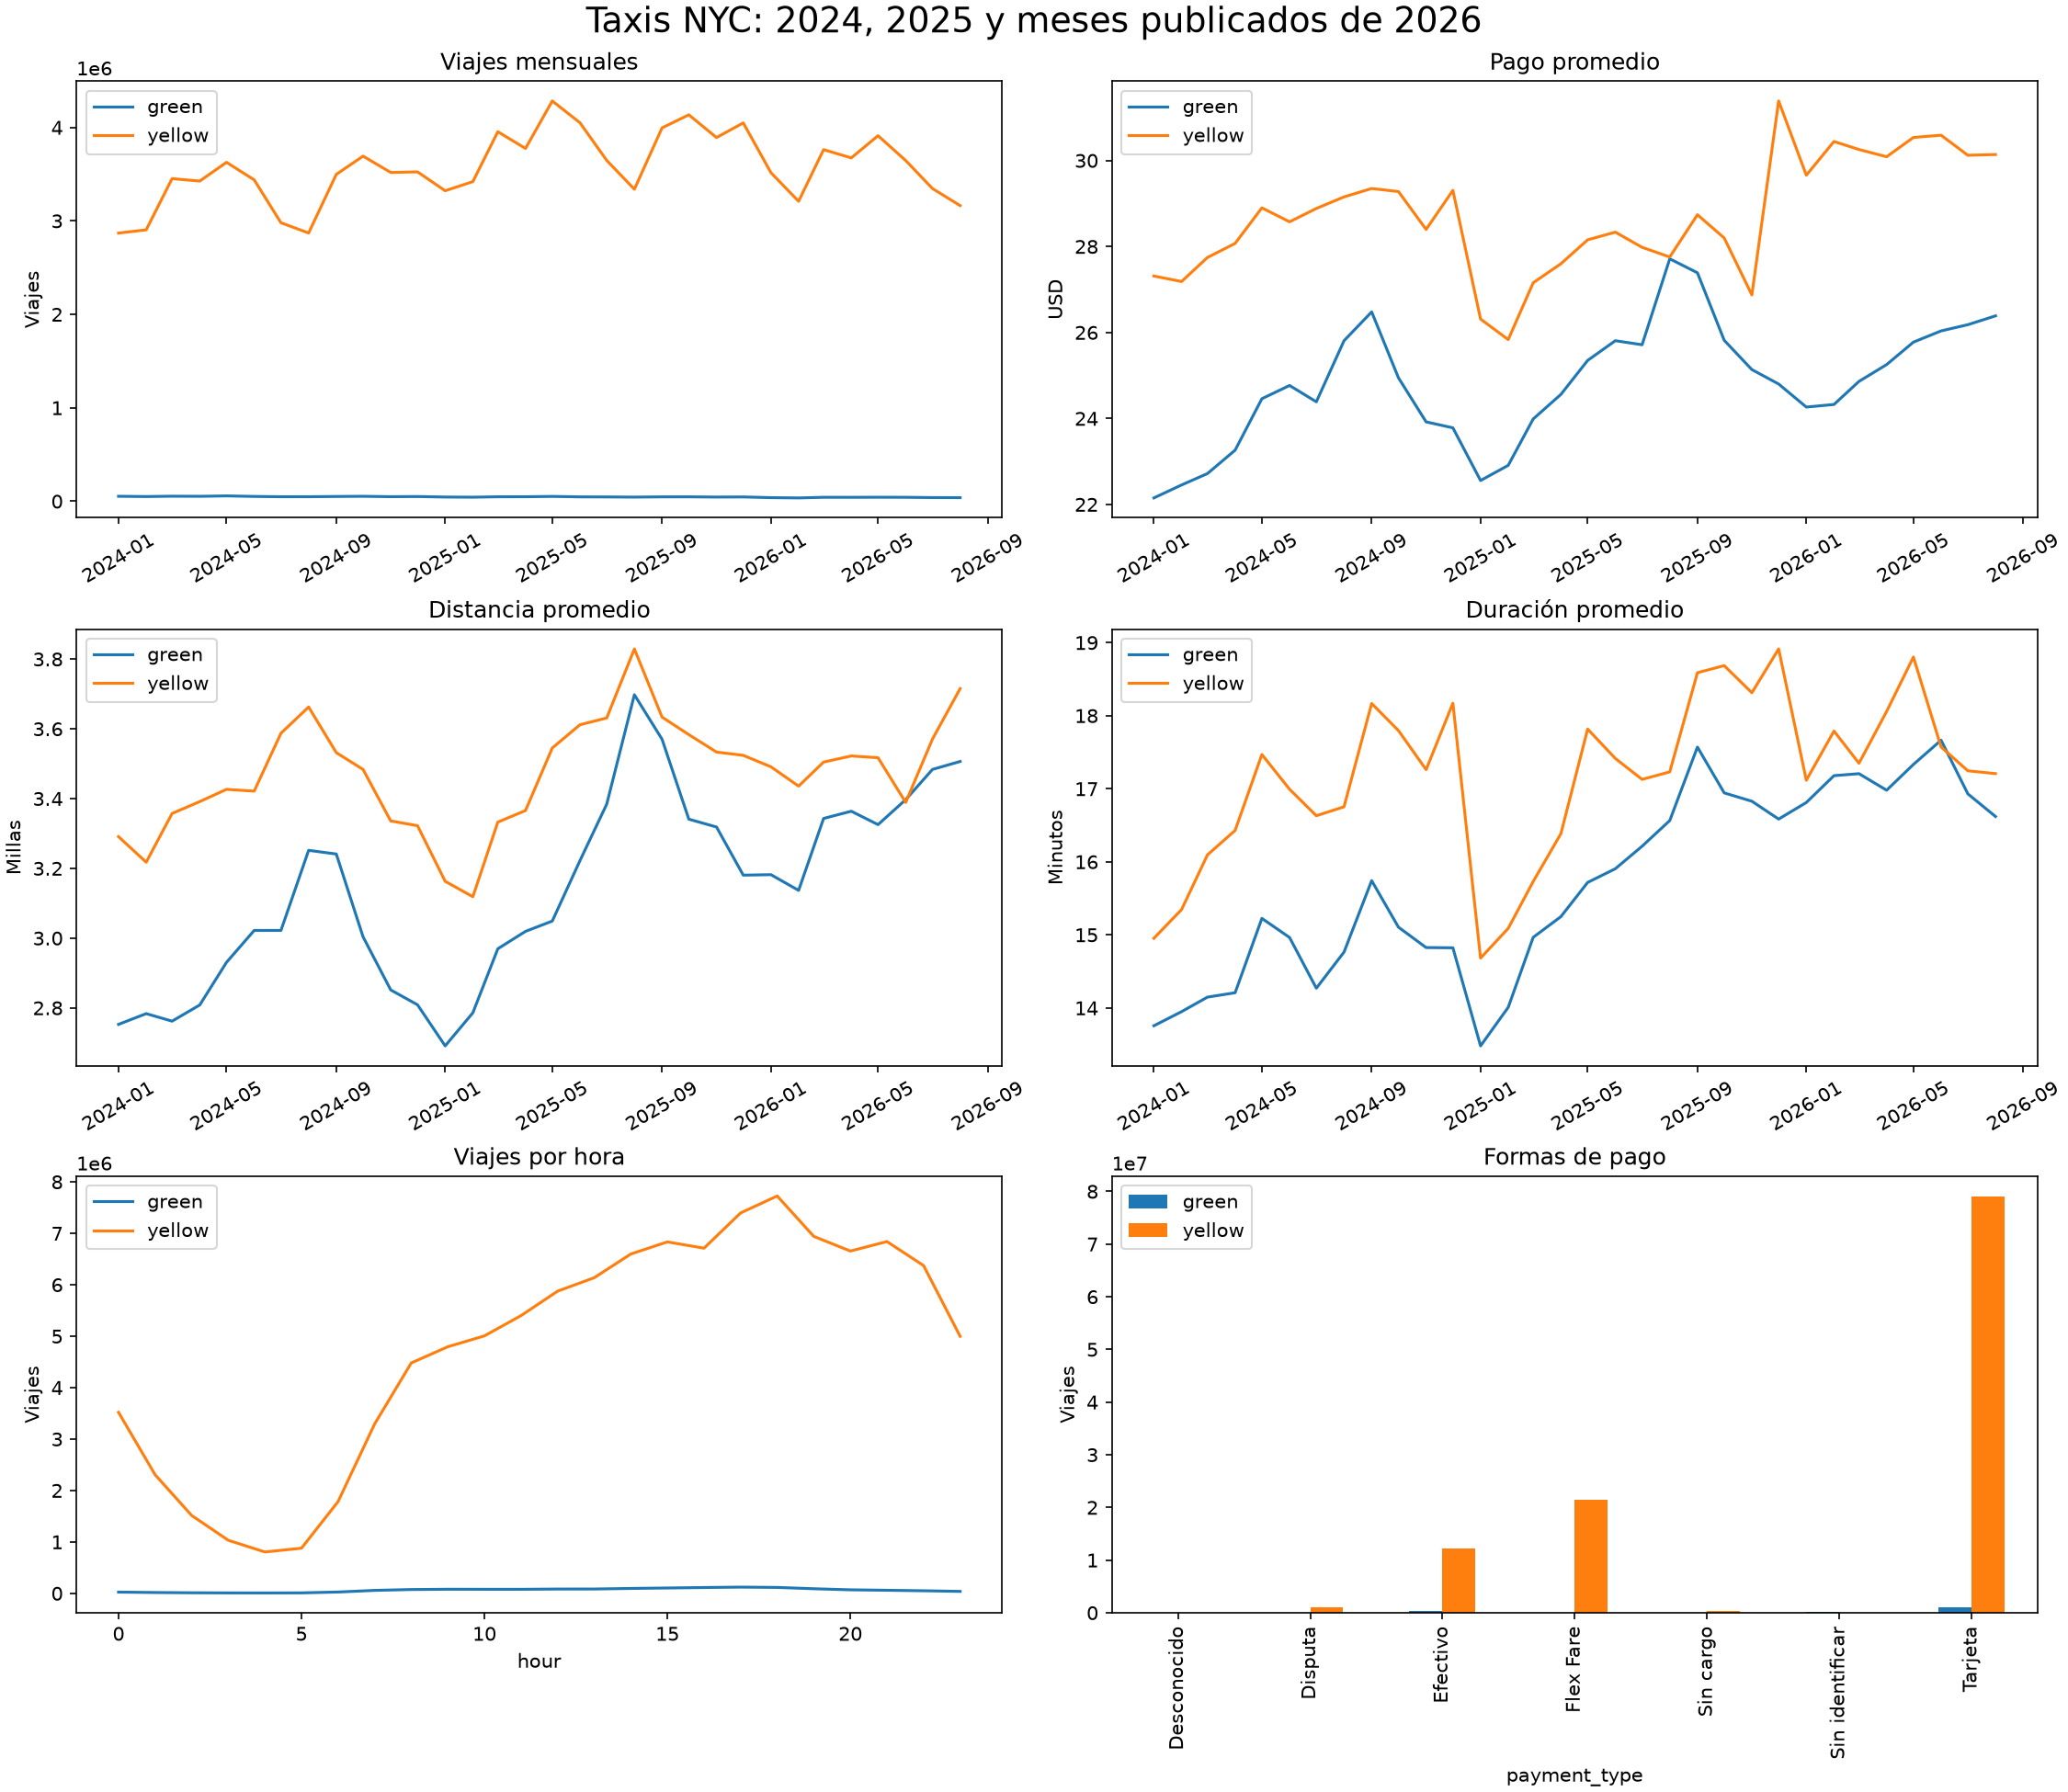

In [8]:
display(Image(filename=str(root / 'docs/dashboard/dashboard.png')))
con.close()